<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict, defaultdict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# nac workflow

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "pbmc8k":
    leiden_resolution = 1.0
else:
    raise ValueError(f"Unknown dataset_name: {dataset_name}")

adata_path_raw = f"{data_dir}/kb_count_out_nac/counts_unfiltered/adata.h5ad"
adata_types = ["spliced", "unspliced", "ambiguous"]

In [5]:
# !cd {data_dir} && wget https://s3-us-west-2.amazonaws.com/10x.files/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_fastqs.tar && tar -xvf pbmc8k_fastqs.tar
fastqs_sorted = sorted([os.path.join(data_dir, "fastqs", f) for f in os.listdir(os.path.join(data_dir, "fastqs")) if f.endswith(".fastq.gz") and "I1" not in f])
fastqs_sorted = " ".join(fastqs_sorted)

data_dir_parent = os.path.dirname(data_dir)
kb_ref_out_nac = os.path.join(data_dir_parent, "kb_ref_out_nac")
os.makedirs(kb_ref_out_nac, exist_ok=True)
!echo kb ref -i {kb_ref_out_nac}/index.idx -g {kb_ref_out_nac}/t2g.txt -f1 {kb_ref_out_nac}/f1.fa -f2 {kb_ref_out_nac}/f2.fa -c1 {kb_ref_out_nac}/c1.txt -c2 {kb_ref_out_nac}/c2.txt --workflow nac -d human
!echo kb count -i {kb_ref_out_nac}/index.idx -g {kb_ref_out_nac}/t2g.txt -x 10XV2 -c1 {kb_ref_out_nac}/c1.txt -c2 {kb_ref_out_nac}/c2.txt --workflow nac --h5ad -t {threads} -o {data_dir}/kb_count_out_nac {fastqs_sorted}

kb ref -i /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/index.idx -g /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/t2g.txt -f1 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/f1.fa -f2 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/f2.fa -c1 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c1.txt -c2 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c2.txt --workflow nac -d human
kb count -i /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/index.idx -g /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/t2g.txt -x 10XV2 -c1 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c1.txt -c2 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c2.txt --workflow nac --h5ad -t 32 -o /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/kb_count_out_nac /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/fastqs/pbmc8k_S1_L007_R1_001.fastq.gz /home/jrich/Desktop/cellsweep/notebooks/data/pbmc

## Knee plot - use this output to estimate umi_cutoff

In [9]:
adata_raw = cs_utils.load_adata(adata_path_raw)
adata_raw.var_names_make_unique()

adata_spliced = adata_raw.copy()
adata_spliced.X = adata_raw.layers["mature"]

adata_unspliced = adata_raw.copy()
adata_unspliced.X = adata_raw.layers["nascent"]

adata_ambiguous = adata_raw.copy()
adata_ambiguous.X = adata_raw.layers["ambiguous"]

adata_dict = {}
adata_dict["raw_spliced"] = adata_spliced
adata_dict["raw_unspliced"] = adata_unspliced
adata_dict["raw_ambiguous"] = adata_ambiguous

del adata_raw  # avoid confusion

UMI cutoff for expected cells (8381): 460.00
UMI cutoff for expected cells (8381): 520.00
UMI cutoff for expected cells (8381): 926.00


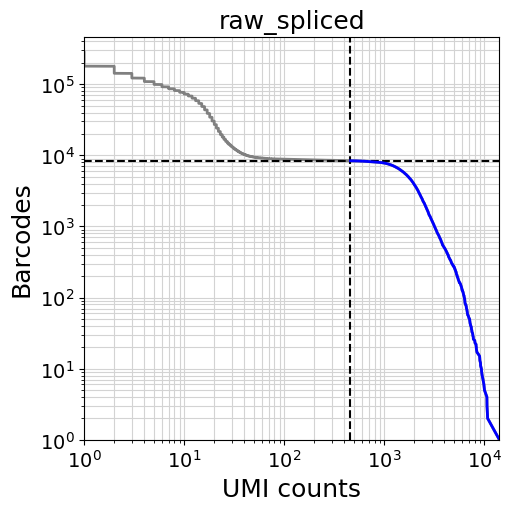

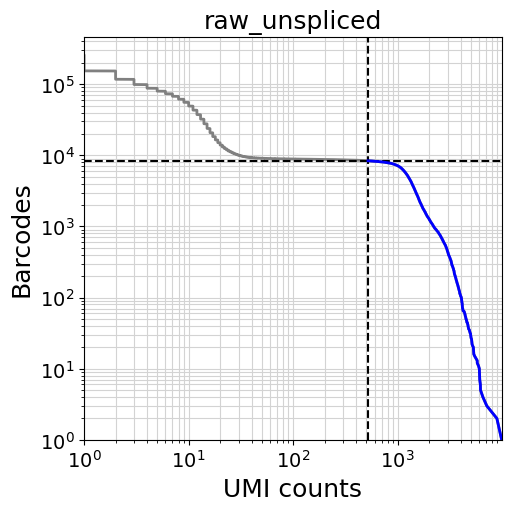

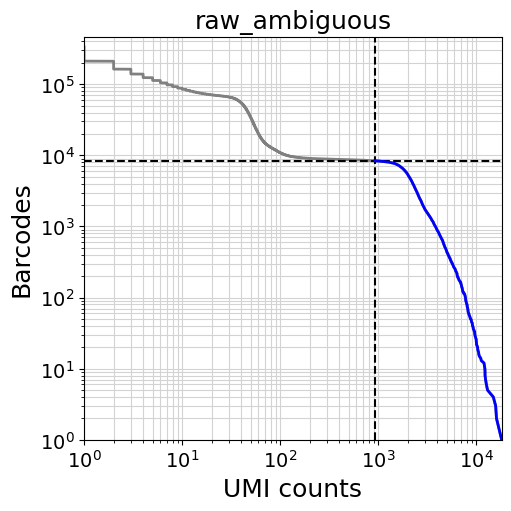

In [10]:
for adata_name, adata in adata_dict.items():
    expected_cells = 8381
    umi_cutoff = cs_utils.knee_plot(adata, transpose=True, expected_cells=expected_cells, title=adata_name, out_path=os.path.join(out_dir, f"knee_plot_{adata_name}.png"))
    adata = cs_utils.infer_empty_droplets(adata, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    adata.var['empty_counts'] = np.array(adata.X[adata.obs['is_empty'].values, :].sum(axis=0)).flatten()
    adata_dict[adata_name] = adata

## cellsweep

In [13]:
for adata_name in adata_types:
    adata_path_cellsweep = os.path.join(data_dir, f"adata_cellsweep_{adata_name}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{adata_name}.log")
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata = adata_dict[f"raw_{adata_name}"].copy()
        if "celltype" not in adata.obs.columns:
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata.obs.index).astype(str).replace("nan", "empty").astype("category")
        adata_cellsweep = denoise_count_matrix(adata, init_alpha=0.9, beta=0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        adata_cellsweep = cs_utils.load_adata(adata_path_cellsweep, verbose=verbose)
    
    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    adata_dict[f"cellsweep_{adata_name}"] = adata_cellsweep

18:46:09 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/adata_cellsweep_spliced.h5ad'
18:46:10 - INFO - Adata initial shape: (8381, 39546)
18:46:10 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
18:46:10 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
18:46:10 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/cellsweep_unspliced.log


18:46:14 - INFO - EM Iter   1: ll=-260.611 log_delta_p=inf min_alpha=0.7893 mean_alpha=0.8678 median_alpha=0.8721 max_alpha=0.9000 beta=0.103180
18:46:14 - DEBUG - 1 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
18:46:14 - INFO - EM Iter   2: ll=-259.730 log_delta_p=inf min_alpha=0.6518 mean_alpha=0.8152 median_alpha=0.8245 max_alpha=0.9000 beta=0.104531
18:46:14 - DEBUG - 1 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
18:46:14 - INFO - EM Iter   3: ll=-258.909 log_delta_p=-1.3917 min_alpha=0.5530 mean_alpha=0.7614 median_alpha=0.7708 max_alpha=0.9000 beta=0.104938
18:46:14 - DEBUG - 1 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
18:46:14 - INFO - EM Iter   4: ll=-258.400 log_delta_p=-1.9639 min_alpha=0.4831 mean_alpha=0.7134 median_alpha=0.7207 max_alpha=0.9000 beta=0.105169
18:46:14 - DE

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/cellsweep_ambiguous.log


18:46:53 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
18:46:53 - INFO - Performing Sparse EM with 32 Numba thread(s)
18:46:53 - INFO - EM Iter   1: ll=-395.242 log_delta_p=inf min_alpha=0.5864 mean_alpha=0.8653 median_alpha=0.8681 max_alpha=0.9000 beta=0.104212
18:46:53 - DEBUG - 2 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
18:46:53 - INFO - EM Iter   2: ll=-393.891 log_delta_p=inf min_alpha=0.1849 mean_alpha=0.8099 median_alpha=0.8143 max_alpha=0.9000 beta=0.106983
18:46:53 - DEBUG - 2 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
18:46:54 - INFO - EM Iter   3: ll=-392.390 log_delta_p=-1.3467 min_alpha=0.0774 mean_alpha=0.7544 median_alpha=0.7572 max_alpha=0.9000 beta=0.108430
18:46:54 - DEBUG - 3 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type 

## Analysis

### Raw vs cellsweep knee plot, scatterplots

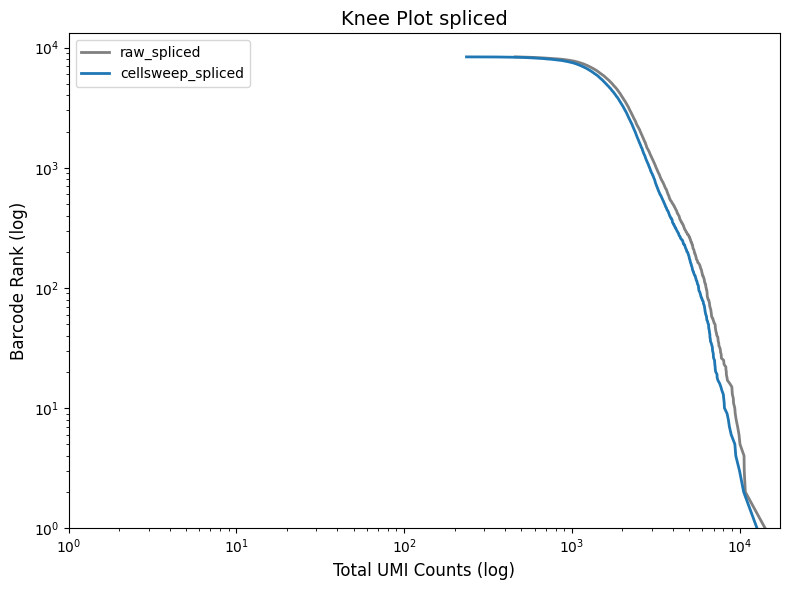

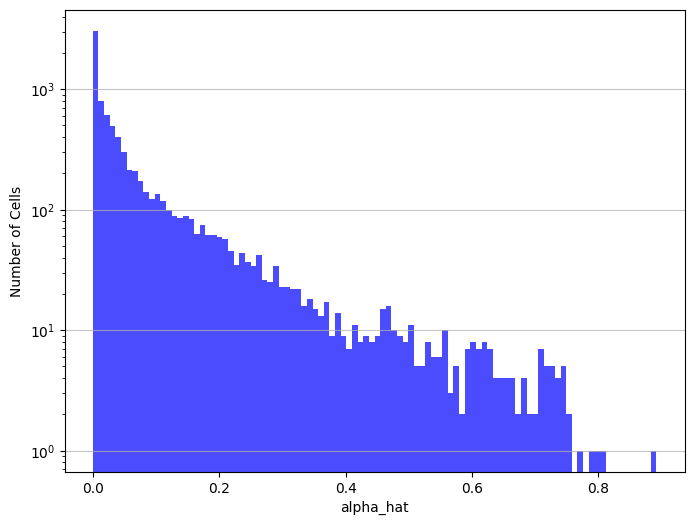

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


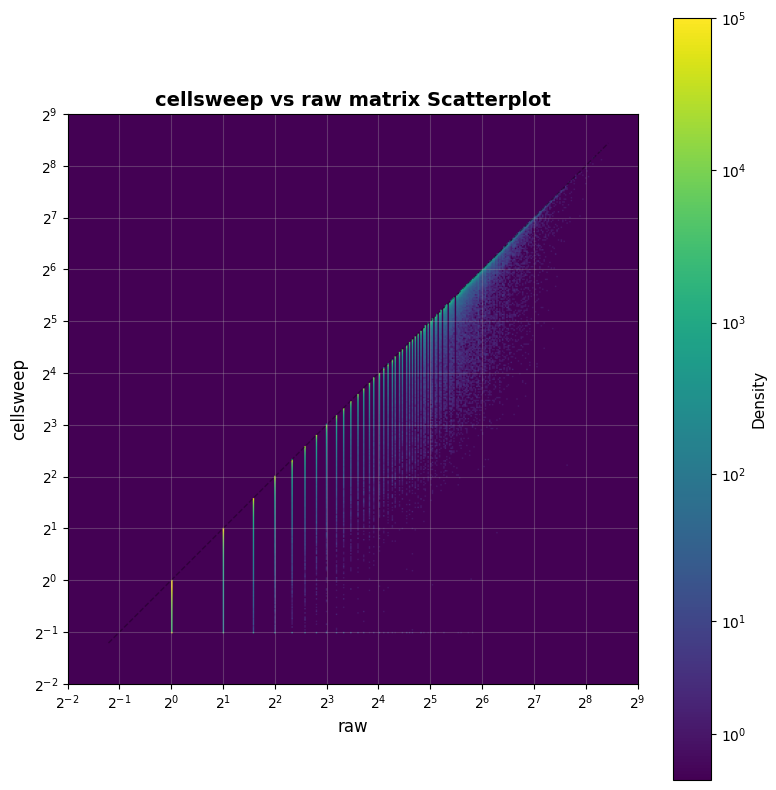

Creating scatterplot...
Calculating scatterplot...


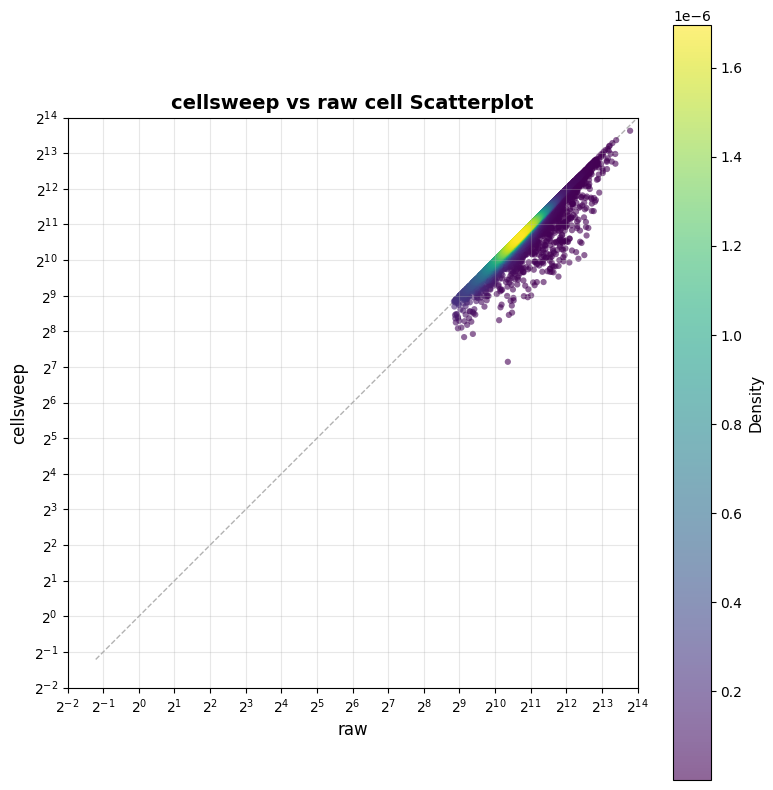

Creating scatterplot...
Calculating scatterplot...


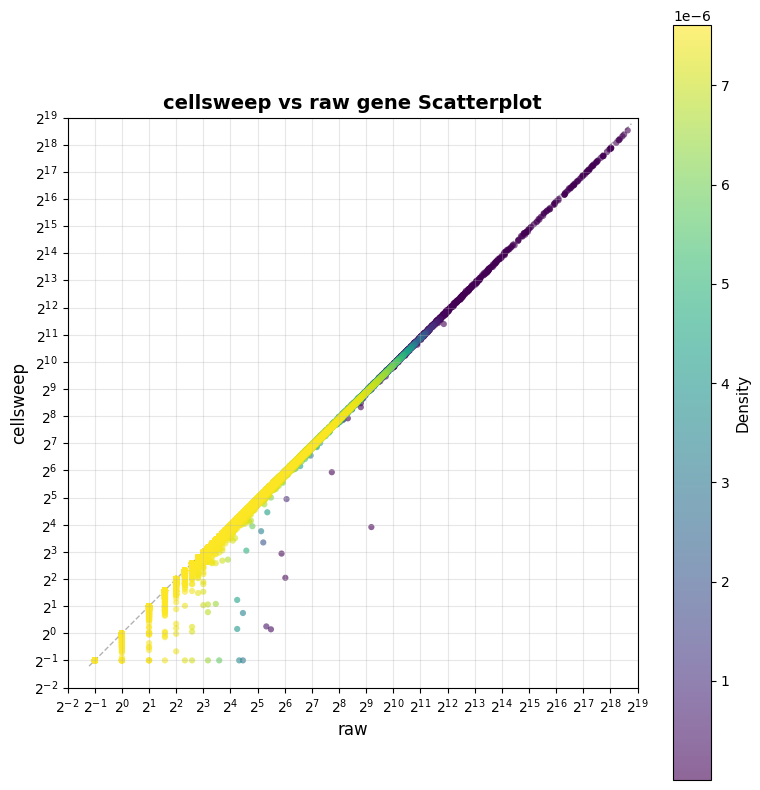

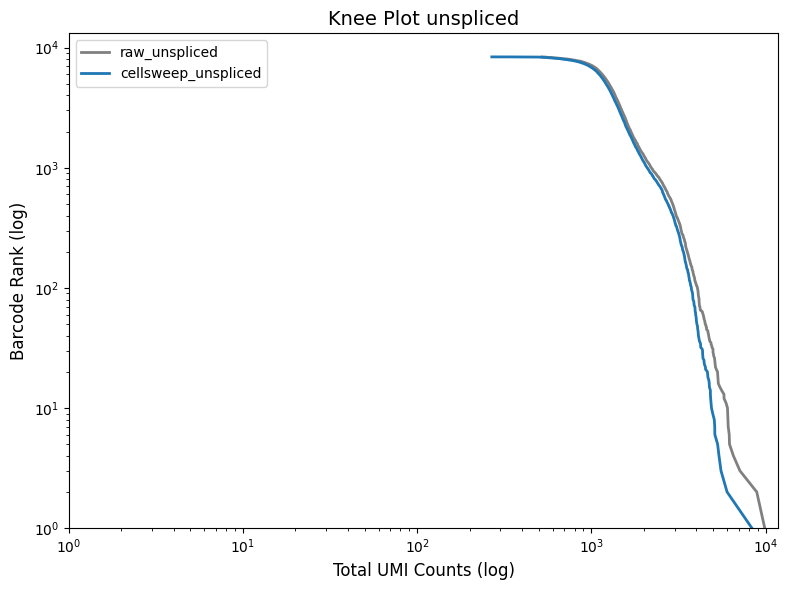

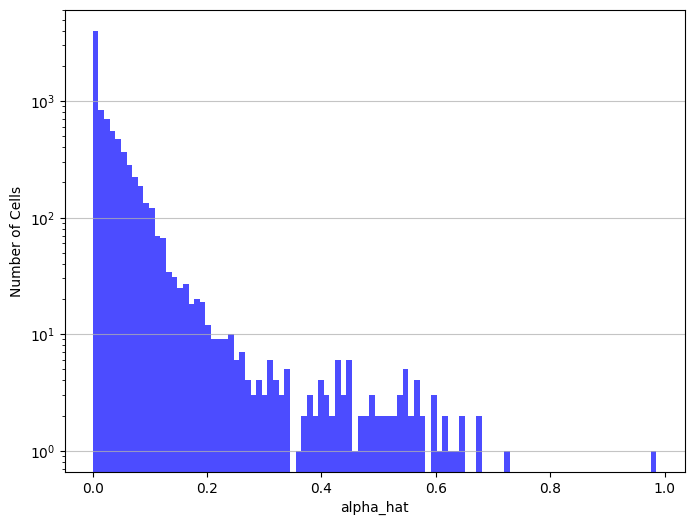

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


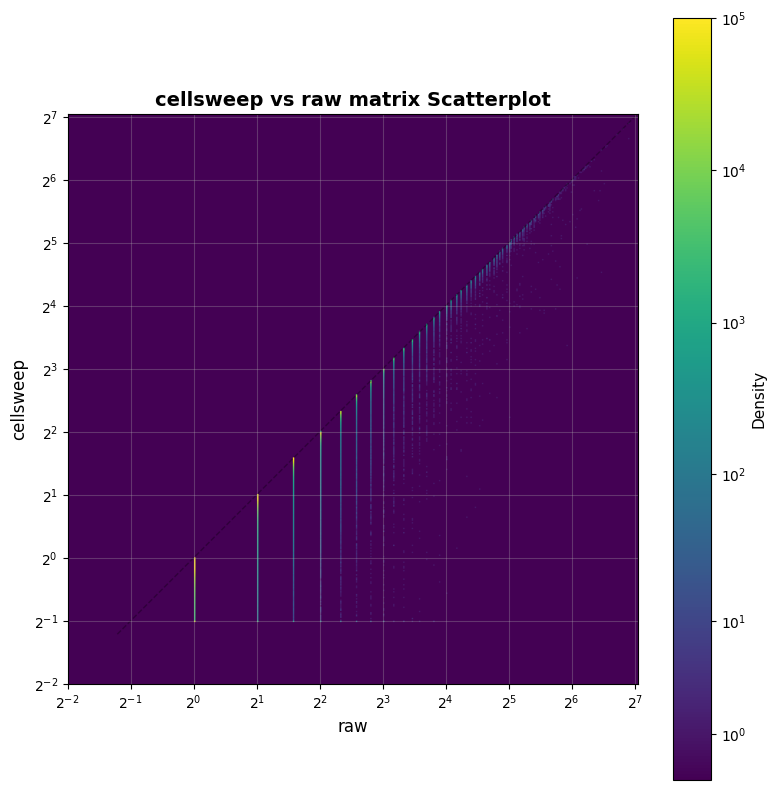

Creating scatterplot...
Calculating scatterplot...


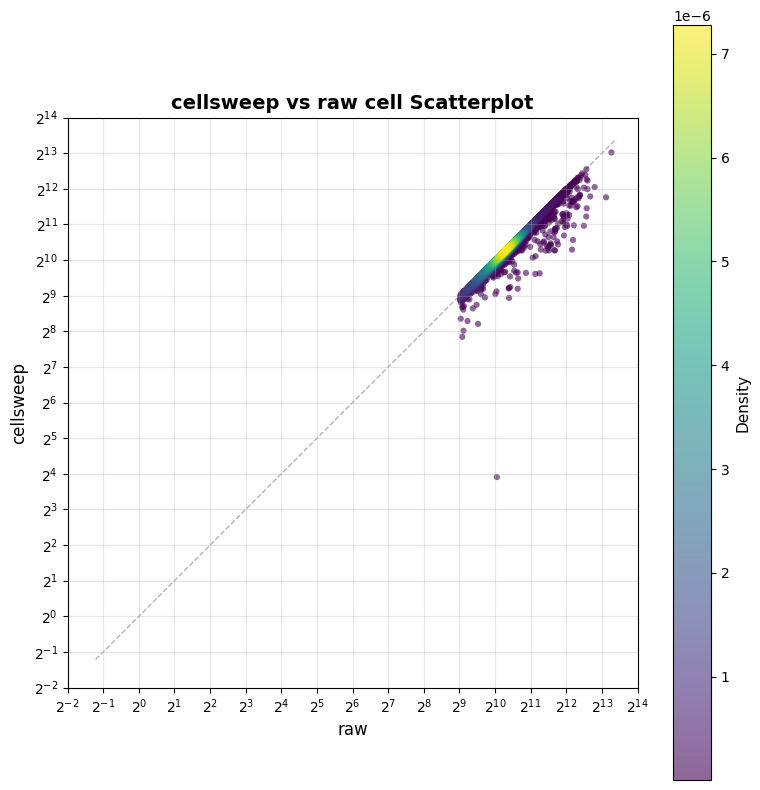

Creating scatterplot...
Calculating scatterplot...


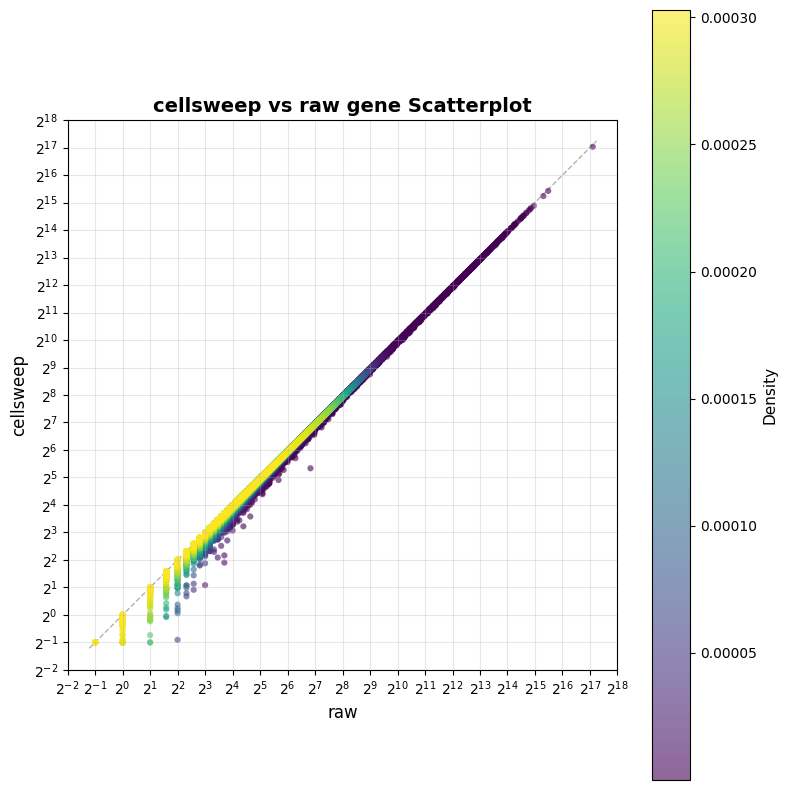

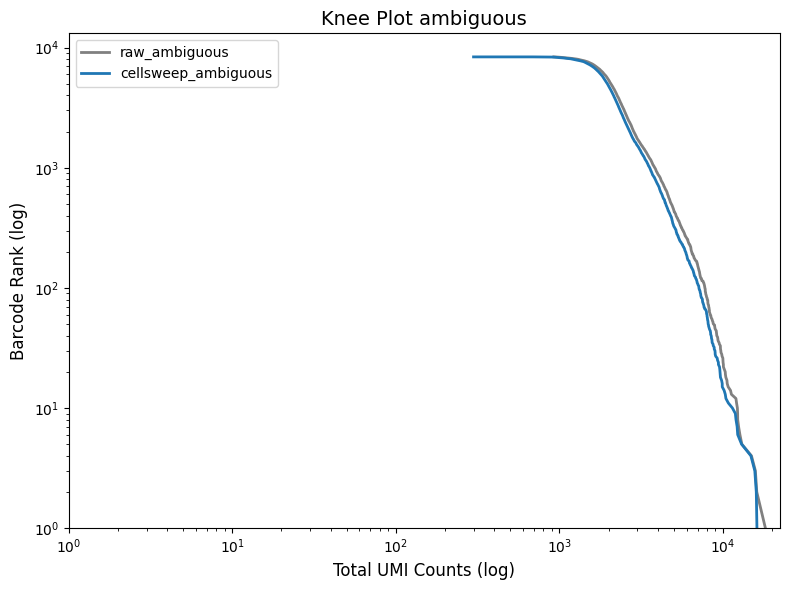

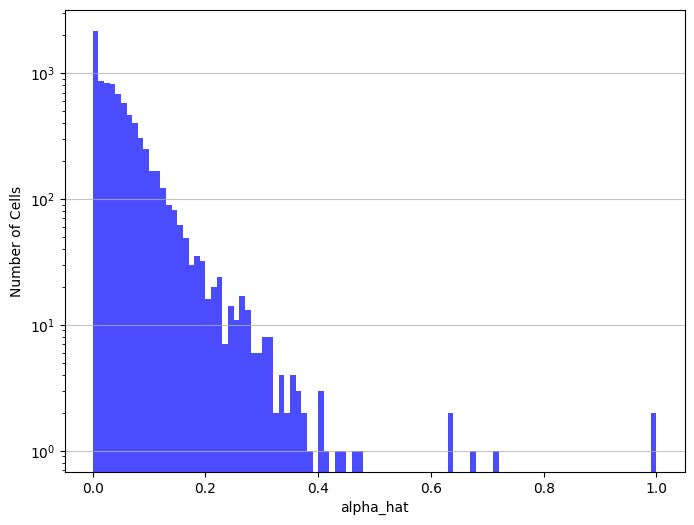

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


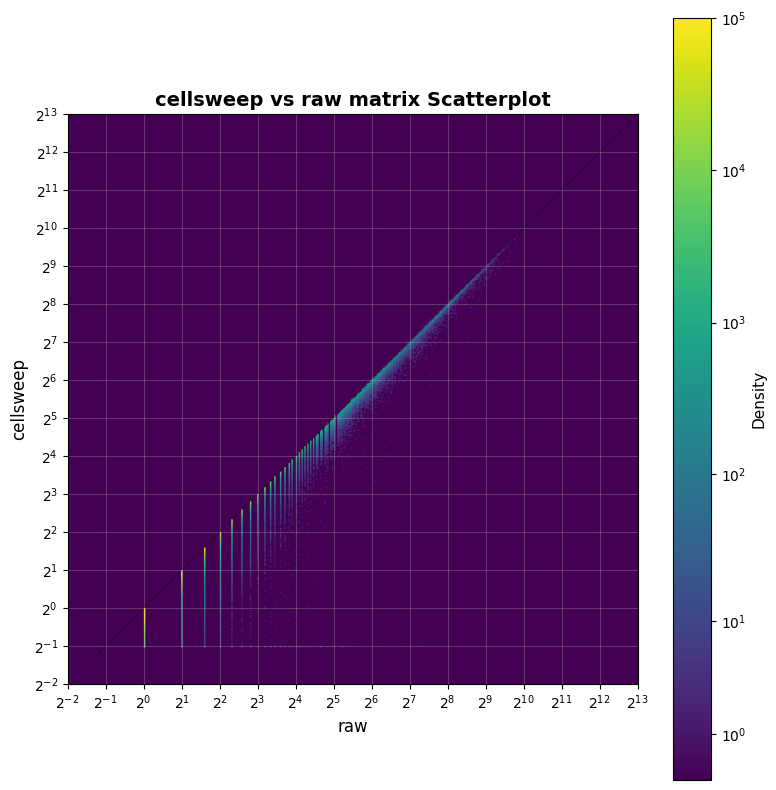

Creating scatterplot...
Calculating scatterplot...


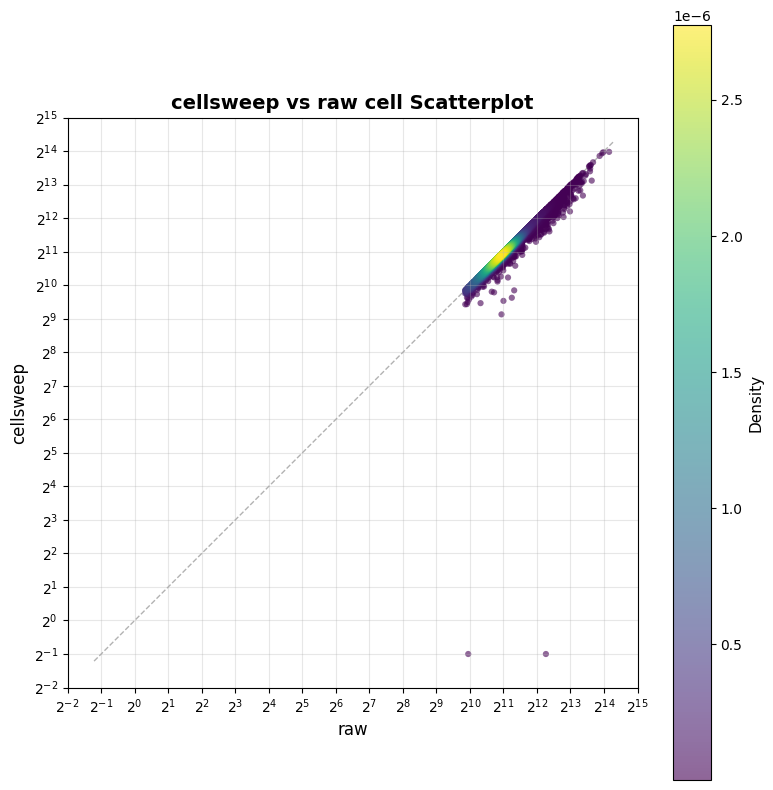

Creating scatterplot...
Calculating scatterplot...


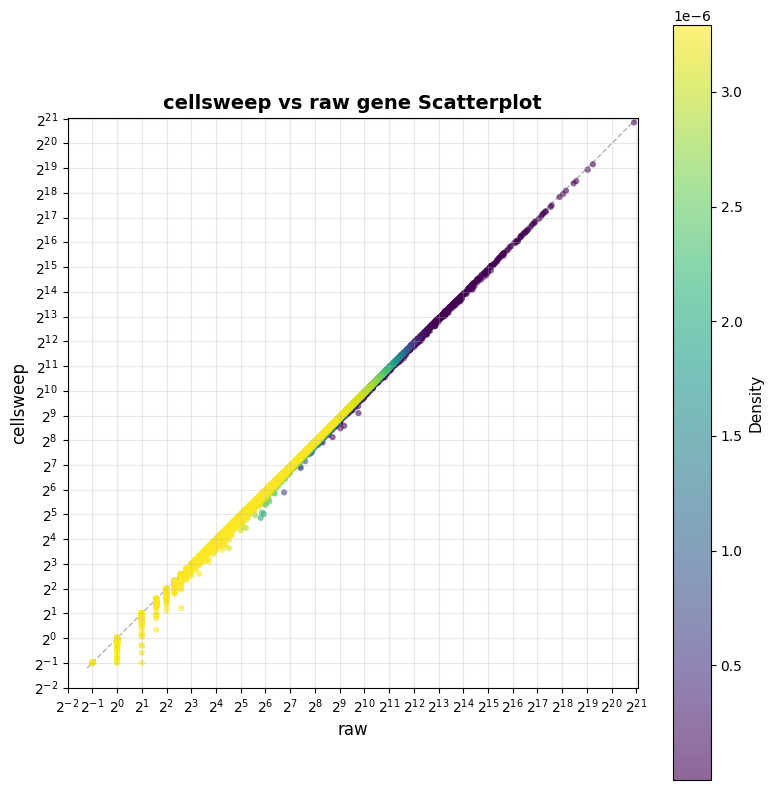

In [ ]:
for adata_name in adata_types:
    adata_raw = adata_dict[f"raw_{adata_name}"]
    adata_cellsweep = adata_dict[f"cellsweep_{adata_name}"]
    
    cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=[f"raw_{adata_name}", f"cellsweep_{adata_name}"], title=f"Knee Plot {adata_name}", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"cellsweep_knee_plot_{adata_name}.png"))
    cs_utils.plot_histogram(adata_cellsweep, col="alpha_hat", out_path=os.path.join(out_dir, f"alpha_hat_histogram_{adata_name}.png"), ylog=True)

    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw matrix scatterplot {adata_name}", out_path=os.path.join(out_dir, f"matrix_expression_scatterplot_{adata_name}.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw cell scatterplot {adata_name}", out_path=os.path.join(out_dir, f"cell_expression_scatterplot_{adata_name}.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw gene scatterplot {adata_name}", out_path=os.path.join(out_dir, f"gene_expression_scatterplot_{adata_name}.png"), show=True)

## Intron analysis

Plotting ambient_hat scatterplot: spliced vs unspliced
Creating scatterplot...
Calculating scatterplot...


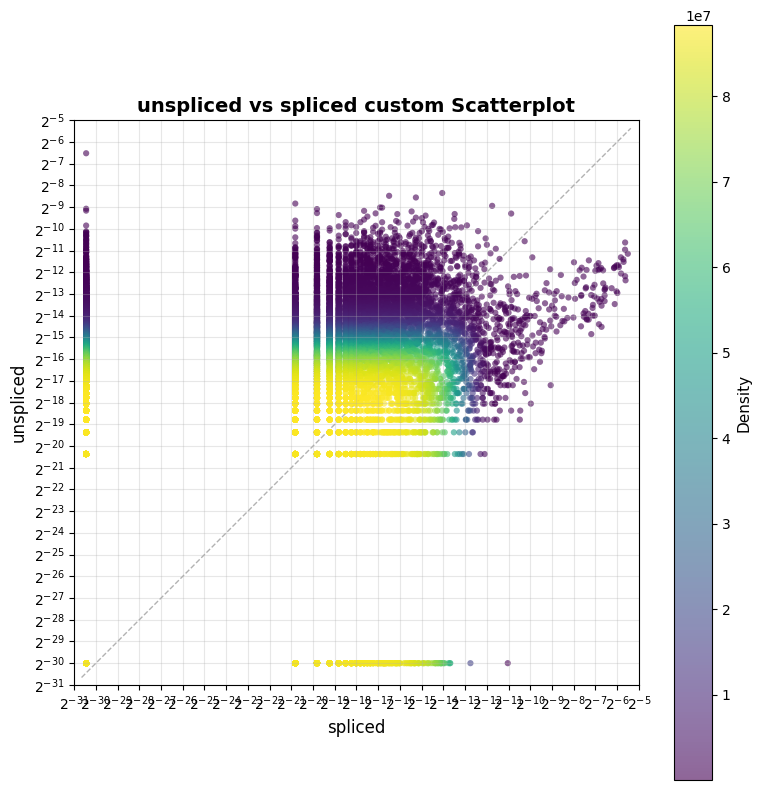

Plotting ambient_hat scatterplot: spliced vs ambiguous
Creating scatterplot...
Calculating scatterplot...


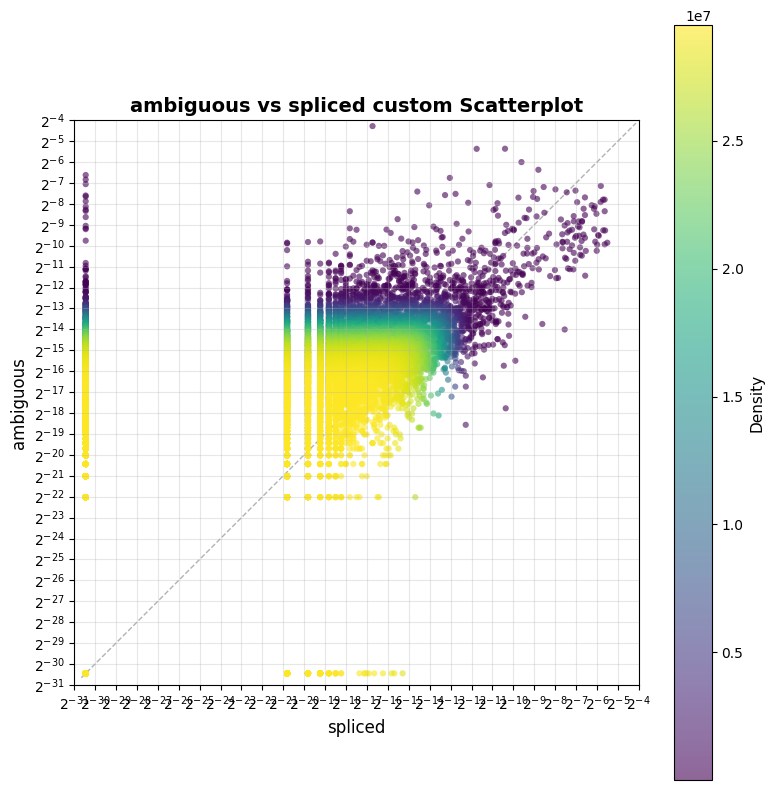

Plotting ambient_hat scatterplot: unspliced vs ambiguous
Creating scatterplot...
Calculating scatterplot...


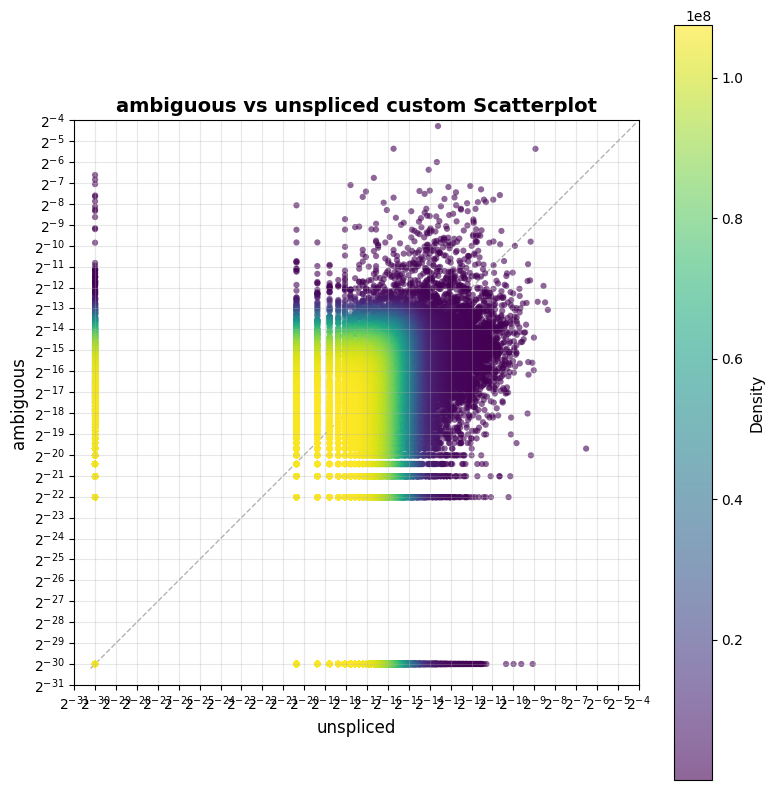

In [ ]:
for adata_name1, adata_name2 in itertools.combinations(adata_types, 2):
    print(f"Plotting ambient_hat scatterplot: {adata_name1} vs {adata_name2}")
    s = adata_dict[f"cellsweep_{adata_name1}"].var["ambient_hat"]
    nonzero_min = s[s > 0].min()
    cs_utils.plot_matrix_scatterplot(adata_dict[f"cellsweep_{adata_name1}"].var["ambient_hat"], adata_dict[f"cellsweep_{adata_name2}"].var["ambient_hat"], minimum=nonzero_min, point_type="custom", density_type="scatter_with_kde", scale="log", x_axis=adata_name1, y_axis=adata_name2, title=f"{adata_name2} vs {adata_name1} ambient_hat gene scatterplot", out_path=os.path.join(out_dir, f"{adata_name1}_vs_{adata_name2}_ambient_hat_scatterplot.png"), show=True)

ambiguous cell contamination AUC: 83.80999999996725
spliced cell contamination AUC: 74.73392325542017
unspliced cell contamination AUC: 82.60912496255082


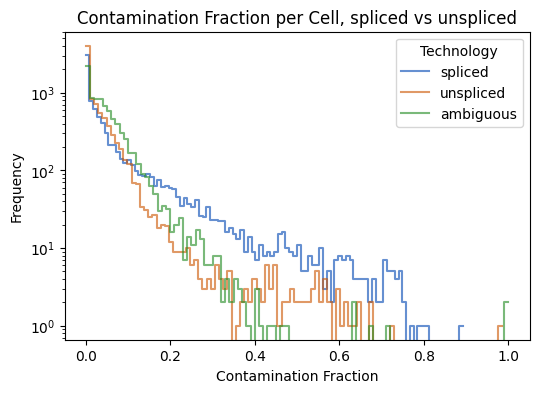

In [16]:
cs_utils.plot_multi_histogram(df1=adata_dict[f"cellsweep_{adata_types[0]}"].obs, df2=adata_dict[f"cellsweep_{adata_types[1]}"].obs, df3=adata_dict[f"cellsweep_{adata_types[2]}"].obs, plotting_column="alpha_hat", df1_name=adata_types[0], df2_name=adata_types[1], df3_name=adata_types[2], out_path=os.path.join(out_dir, "cell_empty_fraction_histogram.png"), show=True)

In [17]:
adata_tmp = ad.read_h5ad("/home/jrich/Desktop/cellsweep/notebooks/data/merfish/Zhuang-ABCA-2-raw.h5ad")

In [19]:
adata_tmp.var.head()

,gene_symbol
gene_identifier,
ENSMUSG00000024798,Htr7
ENSMUSG00000042385,Gzmk
ENSMUSG00000036198,Arhgap36
ENSMUSG00000028780,Sema3c
ENSMUSG00000015843,Rxrg
